# HAR regression with regularisation (ridge)

The three richest **log** HAR specifications from `SimpleHAR_Regressions.ipynb` all add
GVZ (and optionally another asset's RV), so their regressors — gold daily/weekly/monthly
log-RV, log-GVZ, log-SPX / log-crude — are highly collinear, which makes the OLS
coefficients unstable. This notebook re-estimates those three specs with **ridge
regression** to shrink the collinear coefficients. The ridge is fit with **exponentially
decaying observation weights** (λ = 0.94, the RiskMetrics daily standard ⇒ ≈17 effective
observations) so recent data dominates and the fit adapts to short-term dynamics without a
hard window cutoff (no ghost effect). The penalty (alpha) is chosen by **whole-window
leave-one-out / GCV** on the same weighted data (no look-ahead). It compares the ridge
out-of-sample QLIKE against the OLS baseline.

Ridge runs (analogues of the OLS log+GVZ runs in the source notebook):
- **Run 15** — ridge of Run 4:  log HAR + log GVZ
- **Run 16** — ridge of Run 10: log HAR + log SPX + log GVZ
- **Run 17** — ridge of Run 14: log HAR + log crude + log GVZ

In [13]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

# Same aligned daily realized-variance panel used by SimpleHAR_Regressions.ipynb
data = pd.read_parquet("merged_RV_GVZ.parquet")
rv = data["RV_gold"].astype(float)

WINDOW = 500      # rolling estimation window (matches the OLS runs)
EPS = 1e-6        # QLIKE forecast floor

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"Columns available: {list(data.columns)}")

RV_gold: 4114 obs, 2010-01-04 .. 2026-05-29
Columns available: ['RV_gold', 'RV_crude', 'RV_ES', 'GVZ_close']


In [14]:
# ===========================================================================
# Cell 2 — Build the 3 log+GVZ design tables (mirror SimpleHAR Cells 7 & 11)
# ===========================================================================
# Log-HAR components on x = log(RV_gold):
#   x_d[t]=x_t, x_w[t]=mean(x_{t-4..t}), x_m[t]=mean(x_{t-21..t})
#   y_log[t]=x_{t+1}=log(RV_{t+1}); y_level[t]=RV_{t+1} (kept for QLIKE in levels).
# Exogenous day-t terms are logged and known at the close (no look-ahead).

# Strict positivity required for every logged input
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    """Base log-HAR design + optional logged exogenous day-t columns (dict name->series)."""
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)        # log(RV_{t+1})
    df["y_level"] = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])

# Run 15 / 16 / 17 design tables
d_gvz       = build_log_design({"log_GVZ": log_gvz})
d_spx_gvz   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx})
d_crude_gvz = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude})

for name, df in [("d_gvz", d_gvz), ("d_spx_gvz", d_spx_gvz), ("d_crude_gvz", d_crude_gvz)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 15  log+GVZ        cols:", list(d_gvz.columns),       f"({len(d_gvz)} rows)")
print("Run 16  log+SPX+GVZ    cols:", list(d_spx_gvz.columns),   f"({len(d_spx_gvz)} rows)")
print("Run 17  log+crude+GVZ  cols:", list(d_crude_gvz.columns), f"({len(d_crude_gvz)} rows)")
d_gvz.head()

Run 15  log+GVZ        cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level'] (4092 rows)
Run 16  log+SPX+GVZ    cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level'] (4092 rows)
Run 17  log+crude+GVZ  cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level'] (4092 rows)


,x_d,x_w,x_m,log_GVZ,y_log,y_level
Date,,,,,,
2010-02-03,2.850663,2.981362,2.933665,3.095125,3.580491,35.891145
2010-02-04,3.580491,3.080406,2.967351,3.302849,3.444815,31.337489
2010-02-05,3.444815,3.158204,2.994161,3.317453,2.911737,18.388714
2010-02-08,2.911737,3.146146,2.996290,3.291383,2.940123,18.918172
2010-02-09,2.940123,3.145566,3.005753,3.236716,3.123939,22.735769


In [15]:
# ===========================================================================
# Cell 3 — Shared helpers: QLIKE, OLS baseline, ridge with per-window alpha
# ===========================================================================
# QLIKE (Patton 2011 robust form), floored so log is defined.
def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

# --- OLS baseline (identical protocol to SimpleHAR Cell 13) ---
# 500-day rolling log-space OLS + Duan smearing back-transform -> avg QLIKE.
def rolling_log_qlike_smearing(design, feat_cols, ylog_col, ylevel_col, window=WINDOW):
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Ridge: same rolling protocol, but exponentially weighted (EWMA) ---
# Each observation t-k in the window is weighted by lam**k (lam=0.94, RiskMetrics daily
# standard) so recent data dominates -> ~1/(1-lam) ~= 17 effective obs. This adds recency
# without a hard cutoff (no ghost effect). The penalty alpha is still chosen by RidgeCV's
# efficient whole-window leave-one-out / GCV, now on the weighted data (no look-ahead).
# Standardisation matters because the ridge penalty is scale-dependent.
ALPHAS = np.logspace(-4, 4, 50)
LAMBDA = 0.94     # EWMA decay on observation weights (RiskMetrics daily standard)

def rolling_log_ridge_qlike(design, feat_cols, ylog_col, ylevel_col,
                            alphas=ALPHAS, window=WINDOW, lam=LAMBDA):
    Xf  = design[feat_cols].to_numpy()
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    w = lam ** np.arange(window)[::-1]      # oldest..newest -> lam**(age)
    w = w / w.mean()                         # mean weight 1 (comparable to unweighted)
    fc, ac, alpha_sel = [], [], []
    for t in range(window, len(design)):
        Xw, yw = Xf[t - window:t], yl[t - window:t]
        scaler = StandardScaler().fit(Xw)
        Xw_s = scaler.transform(Xw)
        model = RidgeCV(alphas=alphas, fit_intercept=True).fit(Xw_s, yw, sample_weight=w)  # LOO/GCV
        x_hat = model.predict(scaler.transform(Xf[t:t + 1]))[0]
        smearing = np.average(np.exp(yw - model.predict(Xw_s)), weights=w)   # weighted Duan factor
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t])
        alpha_sel.append(model.alpha_)
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip, np.array(alpha_sel)

eff_n = 1.0 / (1.0 - LAMBDA)
print(f"Helpers ready. Ridge alpha grid: {len(ALPHAS)} pts in [{ALPHAS.min():.0e}, {ALPHAS.max():.0e}]; "
      f"EWMA weights lambda={LAMBDA} (~{eff_n:.0f} effective obs), alpha by whole-window GCV")

Helpers ready. Ridge alpha grid: 50 pts in [1e-04, 1e+04]; EWMA weights lambda=0.94 (~17 effective obs), alpha by whole-window GCV


In [16]:
# ===========================================================================
# Cell 4 — Run OLS baselines + ridge (runs 15-17)
# ===========================================================================
specs = [
    ("Run 15  log+GVZ",       d_gvz,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Run 16  log+SPX+GVZ",   d_spx_gvz,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Run 17  log+crude+GVZ", d_crude_gvz, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
]

rows = []
for label, design, feats in specs:
    q_ols, n_ols, _ = rolling_log_qlike_smearing(design, feats, "y_log", "y_level")
    q_rdg, n_rdg, clip_rdg, alphas = rolling_log_ridge_qlike(design, feats, "y_log", "y_level")
    rows.append({"spec": label, "OLS_QLIKE": q_ols, "Ridge_QLIKE": q_rdg,
                 "delta": q_rdg - q_ols, "mean_alpha": alphas.mean(),
                 "median_alpha": np.median(alphas), "n_forecasts": n_rdg})
    print(f"{label:<24} OLS {q_ols:.6f} | Ridge {q_rdg:.6f}  "
          f"(Δ {q_rdg - q_ols:+.6f})  alpha mean={alphas.mean():.4g}, "
          f"median={np.median(alphas):.4g}")

Run 15  log+GVZ          OLS 0.030577 | Ridge 0.033509  (Δ +0.002932)  alpha mean=2148, median=109.9
Run 16  log+SPX+GVZ      OLS 0.030723 | Ridge 0.033518  (Δ +0.002796)  alpha mean=2372, median=160
Run 17  log+crude+GVZ    OLS 0.030618 | Ridge 0.033843  (Δ +0.003225)  alpha mean=2278, median=160


In [17]:
# ===========================================================================
# Cell 5 — Consolidated OLS-vs-ridge comparison
# ===========================================================================
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
comparison = pd.DataFrame(rows).set_index("spec")
print("Ridge vs OLS (lower QLIKE = better 1-day-ahead forecast):")
print(comparison.to_string())

improved = comparison.index[comparison["delta"] < 0].tolist()
print(f"\nRidge improved QLIKE on: {improved if improved else 'none'}")

best_ols   = comparison["OLS_QLIKE"].idxmin()
best_ridge = comparison["Ridge_QLIKE"].idxmin()
best_all   = comparison[["OLS_QLIKE", "Ridge_QLIKE"]].min().idxmin()
best_val   = comparison[["OLS_QLIKE", "Ridge_QLIKE"]].min().min()
print(f"Best OLS spec:   {best_ols} ({comparison.loc[best_ols, 'OLS_QLIKE']:.6f})")
print(f"Best ridge spec: {best_ridge} ({comparison.loc[best_ridge, 'Ridge_QLIKE']:.6f})")
print(f"Overall best:    {best_all} via {best_val:.6f}")

Ridge vs OLS (lower QLIKE = better 1-day-ahead forecast):
                       OLS_QLIKE  Ridge_QLIKE    delta  mean_alpha  median_alpha  n_forecasts
spec                                                                                         
Run 15  log+GVZ         0.030577     0.033509 0.002932 2148.156716    109.854114         3592
Run 16  log+SPX+GVZ     0.030723     0.033518 0.002796 2372.255302    159.985872         3592
Run 17  log+crude+GVZ   0.030618     0.033843 0.003225 2277.796416    159.985872         3592

Ridge improved QLIKE on: none
Best OLS spec:   Run 15  log+GVZ (0.030577)
Best ridge spec: Run 15  log+GVZ (0.033509)
Overall best:    OLS_QLIKE via 0.030577


In [18]:
# ===========================================================================
# Cell 6 — Lambda sweep: slower EWMA decay (>= 50 effective observations)
# ===========================================================================
# Effective obs ~= 1/(1-lambda). lambda=0.94 (~17 obs) shrank too hard and lost badly;
# here we sweep slower decays that each retain >= 50 effective obs, to test whether milder
# recency helps before the variance cost dominates. Alpha is still chosen per window by
# RidgeCV's whole-window GCV on the weighted data. lambda=0.998 (~500 obs) ~ full window.
LAMBDAS = [0.98, 0.985, 0.99, 0.995, 0.998]   # ~50, 67, 100, 200, 500 effective obs

sweep_rows = []
for lam in LAMBDAS:
    rec = {"lambda": lam, "eff_obs": 1.0 / (1.0 - lam)}
    for label, design, feats in specs:
        q_rdg, _, _, _ = rolling_log_ridge_qlike(design, feats, "y_log", "y_level", lam=lam)
        rec[label] = q_rdg
    sweep_rows.append(rec)
    print(f"lambda={lam} (~{rec['eff_obs']:.0f} obs) done")

sweep = pd.DataFrame(sweep_rows).set_index("lambda")

print("\nOLS baselines (reference):")
for label, *_ in specs:
    print(f"  {label:<22} {comparison.loc[label, 'OLS_QLIKE']:.6f}")

print("\nRidge QLIKE by EWMA lambda (lower = better):")
print(sweep.to_string())

print("\nBest lambda per spec vs its OLS baseline:")
for label, *_ in specs:
    best_lam = sweep[label].idxmin()
    best_q   = sweep.loc[best_lam, label]
    ols_q    = comparison.loc[label, "OLS_QLIKE"]
    flag     = "BEATS OLS" if best_q < ols_q else f"still +{best_q - ols_q:.6f} vs OLS"
    print(f"  {label:<22} best lambda={best_lam} (~{1.0/(1.0-best_lam):.0f} obs) "
          f"-> {best_q:.6f}  ({flag})")

lambda=0.98 (~50 obs) done
lambda=0.985 (~67 obs) done
lambda=0.99 (~100 obs) done
lambda=0.995 (~200 obs) done
lambda=0.998 (~500 obs) done

OLS baselines (reference):
  Run 15  log+GVZ        0.030577
  Run 16  log+SPX+GVZ    0.030723
  Run 17  log+crude+GVZ  0.030618

Ridge QLIKE by EWMA lambda (lower = better):
            eff_obs  Run 15  log+GVZ  Run 16  log+SPX+GVZ  Run 17  log+crude+GVZ
lambda                                                                          
0.980000  50.000000         0.030933             0.031137               0.031115
0.985000  66.666667         0.030644             0.030810               0.030718
0.990000 100.000000         0.030445             0.030570               0.030439
0.995000 200.000000         0.030370             0.030502               0.030363
0.998000 500.000000         0.030473             0.030601               0.030487

Best lambda per spec vs its OLS baseline:
  Run 15  log+GVZ        best lambda=0.995 (~200 obs) -> 0.030370  (BEATS

Run 15  log+GVZ: swept 33 alphas
Run 16  log+SPX+GVZ: swept 33 alphas
Run 17  log+crude+GVZ: swept 33 alphas


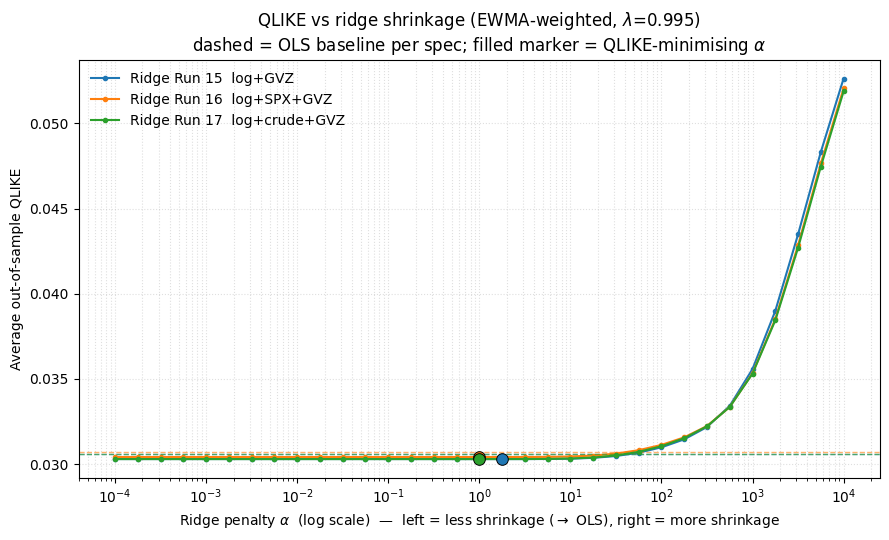


QLIKE-minimising alpha per spec (EWMA lambda=0.995):
  Run 15  log+GVZ        alpha*=    1.78 -> QLIKE 0.030302  (beats OLS)
  Run 16  log+SPX+GVZ    alpha*=       1 -> QLIKE 0.030423  (beats OLS)
  Run 17  log+crude+GVZ  alpha*=       1 -> QLIKE 0.030301  (beats OLS)


In [19]:
# ===========================================================================
# Cell 7 — QLIKE vs ridge penalty (alpha) at the best EWMA decay (lambda=0.995)
# ===========================================================================
# Instead of GCV-selecting alpha per window, we FIX alpha at each grid value and re-run the
# full rolling out-of-sample protocol (EWMA-weighted, lambda=0.995) to trace how average
# QLIKE responds to increasing / decreasing the ridge shrinkage. Small alpha -> ~OLS (no
# shrinkage); large alpha -> heavy shrinkage toward zero coefficients. The grid extends down
# to 1e-4 to confirm the curve flattens to the (weighted) OLS limit at negligible shrinkage.
BEST_LAMBDA = 0.995
ALPHA_GRID  = np.logspace(-4, 4, 33)     # ridge penalty sweep (log-spaced, ~4 pts/decade)

def rolling_log_ridge_fixed_alpha(design, feat_cols, ylog_col, ylevel_col,
                                  alpha, lam=BEST_LAMBDA, window=WINDOW):
    """Rolling EWMA-weighted ridge with a FIXED alpha (no GCV) -> average QLIKE."""
    Xf  = design[feat_cols].to_numpy()
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    w = lam ** np.arange(window)[::-1]
    w = w / w.mean()
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = Xf[t - window:t], yl[t - window:t]
        scaler = StandardScaler().fit(Xw)
        Xw_s = scaler.transform(Xw)
        model = Ridge(alpha=alpha, fit_intercept=True).fit(Xw_s, yw, sample_weight=w)
        x_hat = model.predict(scaler.transform(Xf[t:t + 1]))[0]
        smearing = np.average(np.exp(yw - model.predict(Xw_s)), weights=w)
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t])
    q, _ = _qlike(np.array(ac), np.array(fc))
    return q.mean()

# QLIKE(alpha) curve for each spec
alpha_curves = {}
for label, design, feats in specs:
    alpha_curves[label] = np.array([
        rolling_log_ridge_fixed_alpha(design, feats, "y_log", "y_level", a)
        for a in ALPHA_GRID
    ])
    print(f"{label}: swept {len(ALPHA_GRID)} alphas")

# --- Plot: average QLIKE vs ridge penalty alpha (one line per spec) ---
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (label, *_), c in zip(specs, colors):
    curve = alpha_curves[label]
    ax.plot(ALPHA_GRID, curve, marker="o", ms=3, color=c, label=f"Ridge {label}")
    a_min = ALPHA_GRID[np.argmin(curve)]
    ax.scatter([a_min], [curve.min()], color=c, s=70, zorder=5,
               edgecolor="black", linewidth=0.7)
    ax.axhline(comparison.loc[label, "OLS_QLIKE"], color=c, ls="--", lw=1, alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel(r"Ridge penalty $\alpha$  (log scale)  —  left = less shrinkage ($\to$ OLS), right = more shrinkage")
ax.set_ylabel("Average out-of-sample QLIKE")
ax.set_title(f"QLIKE vs ridge shrinkage (EWMA-weighted, $\\lambda$={BEST_LAMBDA})\n"
             "dashed = OLS baseline per spec; filled marker = QLIKE-minimising $\\alpha$")
ax.legend(frameon=False)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig("qlike_vs_ridge_alpha.png", dpi=150)
plt.show()

# Report the minimising alpha per spec vs OLS
print("\nQLIKE-minimising alpha per spec (EWMA lambda=0.995):")
for label, *_ in specs:
    curve = alpha_curves[label]
    a_min = ALPHA_GRID[np.argmin(curve)]
    q_min = curve.min()
    ols_q = comparison.loc[label, "OLS_QLIKE"]
    flag  = "beats OLS" if q_min < ols_q else f"+{q_min - ols_q:.6f} vs OLS"
    print(f"  {label:<22} alpha*={a_min:8.3g} -> QLIKE {q_min:.6f}  ({flag})")